# Mini-Project 2
*Kim Concepcion Nielsen*

*Course : Numerical Scientific Computing 2026*

## Hardware Specs
* CPU Model: Quad-Core Intel Core i7
* CPU Cores: 4
* RAM: 16GB
* L2-buffer per core: 256 kB
* L3-buffer: 8 MB

## Operating System Information
* System version: macOS 13.7.8 (22H730)

## Library versions
* Python: 3.11.14

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 1.26.4 |
| numba      | 0.63.1 |
| matplotlib | 3.10.8 |
| line_profiler  | 5.0.2  |
| memory_profiler| 0.61.0 |

### Measurement Methodology
...

---

## Multiprocessing

### Monte Carlo π

**Exercise 1: Serial Implementation**

In [1]:
import math, random, time, statistics
import matplotlib.pyplot as plt

def estimate_pi_serial(num_samples):
    hits_inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            hits_inside_circle += 1
    return 4 * hits_inside_circle / num_samples

def do_serial():
    num_samples  = 10_000_000
    times        = []
    
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    print(f"pi estimate: {pi_estimate:.6f} (error: {abs(pi_estimate-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

if __name__ == '__main__':
    do_serial()
    do_serial()
    do_serial()

pi estimate: 3.141861 (error: 0.000268)
Serial time: 2.837s
pi estimate: 3.141796 (error: 0.000203)
Serial time: 2.712s
pi estimate: 3.141183 (error: 0.000410)
Serial time: 2.833s


Questions:
* How accurate is the estimate? Run several times — does it vary? *Yes the serial time varies, but the change is quite small*
* What is the serial time? This will be your speedup denominator in E3. *Serial time lies between 2.7-2.8 seconds*

**Exercise 2: Parallel Implementation (Run this code in .py file)**

In [ ]:
from multiprocessing import Pool
import os, random, time, statistics
import matplotlib.pyplot as plt

def estimate_pi_chunk(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle

def estimate_pi_parallel(num_samples, num_processes=4):
    samples_per_process = num_samples // num_processes
    tasks = [samples_per_process] * num_processes
    with Pool(processes=num_processes) as pool:
        results = pool.map(estimate_pi_chunk, tasks)
    return 4 * sum(results) / num_samples

if __name__ == '__main__':
    phy_cores = os.cpu_count() / 2
    print(f'Number of cores: {phy_cores}')
    
    num_samples = 10_000_000

    results = []
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        pi_0_est = 0
        
        for idx in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            
            t1 = time.perf_counter() - t0
            times.append(t1)
        
        t = statistics.median(times)        
        new_result = {
            'workers' : num_proc,
            'pi' : pi_est,
            't': t,
            'speedup': 0,
            'eff' : 0,
            's' : 0
        }
        
        results.append(new_result)

    # Compute speedups
    t0 = results[0]['t']
    for result in results:
        result['speedup'] = t0 / result['t']
        result['eff']     = result['speedup'] / result['workers']
        
        # avoid division by 0 :-P
        if result['workers'] > 1:
            result['s'] = (1/result['speedup'] - 1/result['workers']) / (1 - 1/result['workers'])
        
        print(f"{result['workers']:2d} workers t={result['t']:.3f}s pi={result['pi']:.6f} sp={result['speedup']:.3f} eff={result['eff']*100.0:.3f}% s={result['s']:.3f}")
    
    # Plotting
    workers   = [ r['workers'] for r in results ]
    times     = [ r['t'] for r in results ]
    speedups  = [ r['speedup'] for r in results ]

    plt.figure()
    plt.plot(workers, times, marker='o', label='Measured execution time vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Execution Time [s]')
    plt.title('Execution time vs number of cores')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    ideal = workers
    plt.figure()
    plt.plot(workers, ideal, 'k--', label='Ideal linear')
    plt.plot(workers, speedups, marker='o', label='Measured speedup vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Speedup')
    plt.title('Speedup vs workers')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

```
Number of cores: 6.0
 1 workers t=3.338s pi=3.141318 sp=1.000 eff=100.000% s=0.000
 2 workers t=2.246s pi=3.141794 sp=1.487 eff=74.331% s=0.345
 3 workers t=1.876s pi=3.142806 sp=1.780 eff=59.324% s=0.343
 4 workers t=1.850s pi=3.141247 sp=1.805 eff=45.122% s=0.405
 5 workers t=1.828s pi=3.141680 sp=1.826 eff=36.520% s=0.435
 6 workers t=1.671s pi=3.141567 sp=1.998 eff=33.296% s=0.401
 7 workers t=1.747s pi=3.141666 sp=1.910 eff=27.292% s=0.444
 8 workers t=1.912s pi=3.141110 sp=1.746 eff=21.825% s=0.512
 9 workers t=1.750s pi=3.141722 sp=1.907 eff=21.190% s=0.465
10 workers t=1.908s pi=3.140892 sp=1.750 eff=17.497% s=0.524
11 workers t=1.954s pi=3.141759 sp=1.708 eff=15.529% s=0.544
12 workers t=2.067s pi=3.141109 sp=1.615 eff=13.460% s=0.585
```

Questions:
* Do all worker counts give the same ˆπ? Why or why not? *No. When each created task executes estimate_pi_chunk() which generates new random x and y points. Because of this the pi values will never be identical*
* At which count do you first see a meaningful speedup? *Based on the execution time results, I would say that the first big speedup happens at 2 workers. The biggest speedup seems to be around 6 workers*

**Exercise 3: Analyze Results**

Parallel efficiency: E_p = S_p/p - fraction of ideal speedup per core (100%=perfect).
For each worker count (1 to cpu_count()), tabulate: workers | time (s) | speedup S_p | efficiency E_p (%)

Questions to discuss:
1. At which worker count $p^∗$ is speedup maximum? *Based on the code output above, the biggest speedup seems to be at 6 workers*
2. Does speedup plateau or drop beyond $p^∗$? Why? *After 6 workers, the speedup drops. This could be due to e.g. IPC overhead, which is a sequential process.*
3. Back-solve implied serial fraction: $s=\frac{1/s_{p^*}-1/p^*}{1-1/p^*}$ what fraction of time is effectively serial (IPC overhead + spawning)? *According to the code output the serial fraction for e.g. 6 workers where we have maximum speedup, the serial fraction is 0.401*

(Optional) Plot: workers (x) vs. speedup (y) — actual and ideal linear.

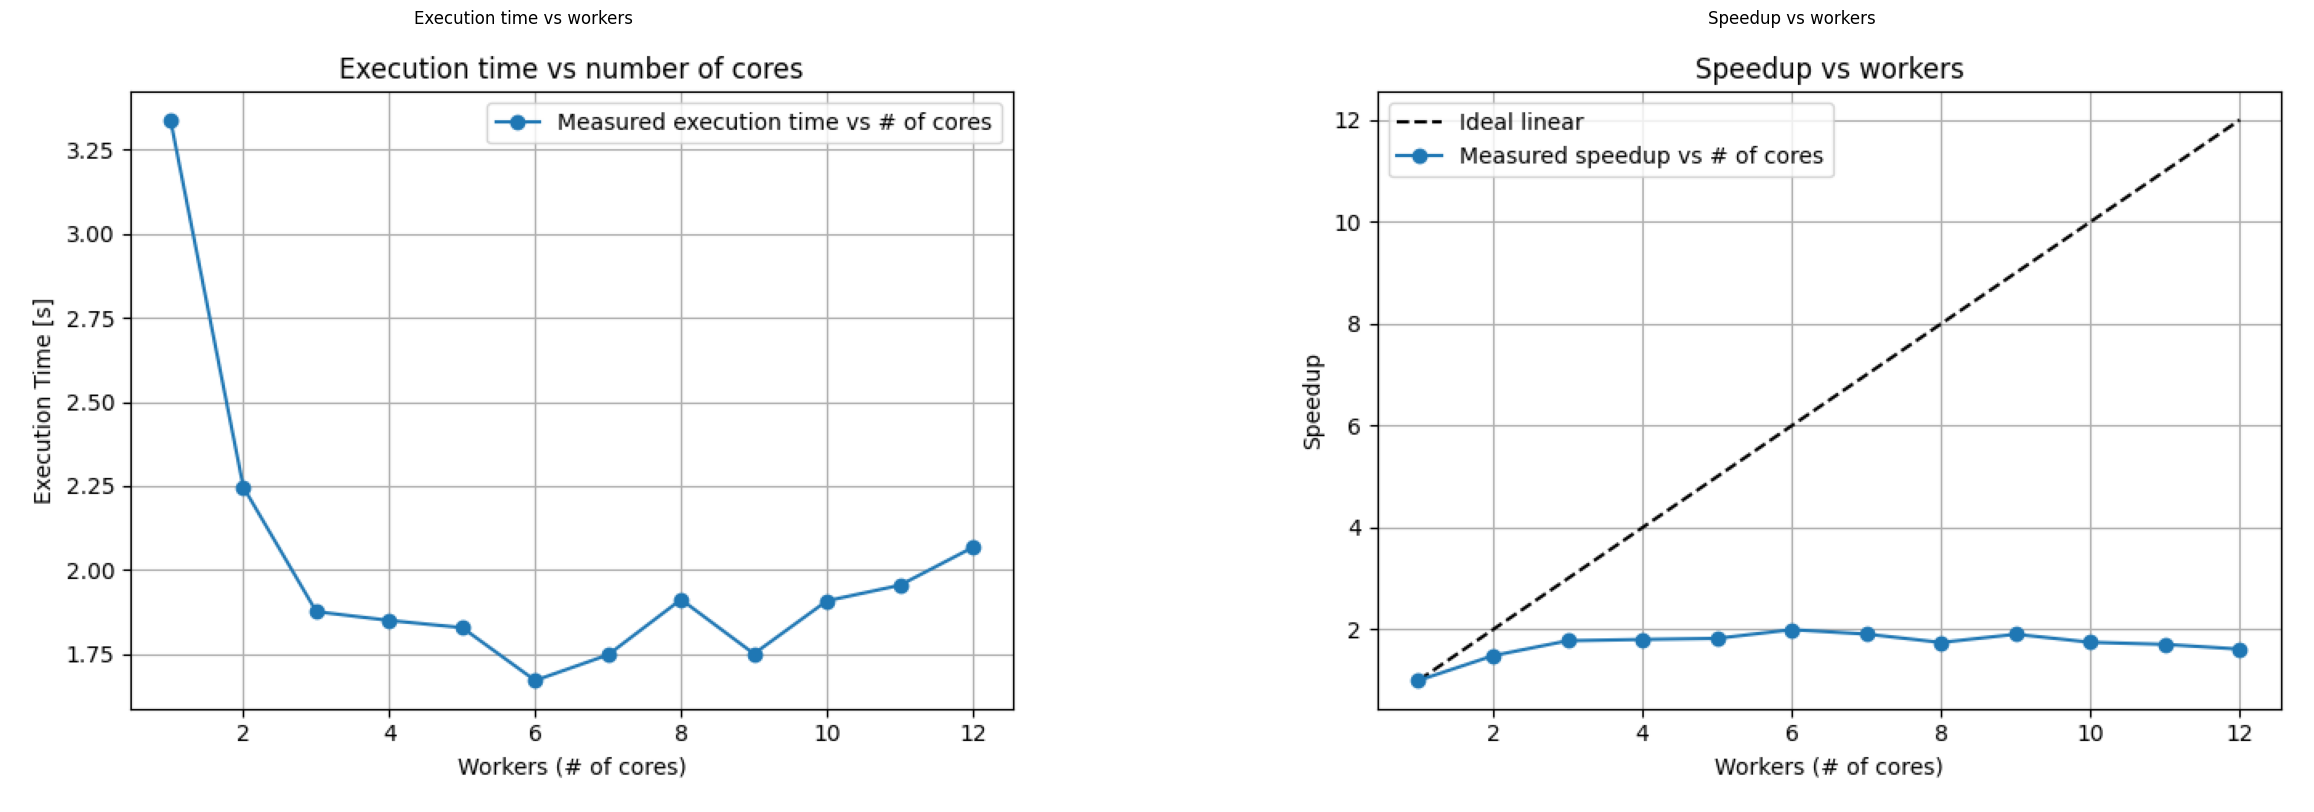

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('execution_time_vs_workers_home_pc.png')
img2 = mpimg.imread('speedup_vs_workers_home_pc.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Execution time vs workers')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Speedup vs workers')
ax[1].axis('off')

plt.show()

### Parallel Mandelbrot

**M1 Refactor Code**

**M2 Parallel Implementation**

*Parallel Mandelbrot vs Serial Mandelbrot results*

**M3 Benchmark**

---

## Dask - Local Cluster

### Code

### Milestones

**Milestone 1:**

---

## Dask - AAU Strato HPC cluster

### Code

### Milestones

**Milestone 1:**